In [23]:
using LinearAlgebra
using DataFrames

In [24]:
##alles was hier kommt sind nur rundungsfunktionen und eine voreinstellung für die Achsenbeschriftung


using CSV
# # using CSVFiles
using CairoMakie
using LaTeXStrings

using DataFrames
using Measurements
import Measurements: value, uncertainty
using Statistics



using Random, Statistics

function first_significant_digit(x::Real)
    x == 0 && return 0  # Sonderfall: Wenn x genau 0 ist, gibt es keine signifikante Stelle, also gib 0 zurück.

    absx = abs(x)  # Der Betrag der Zahl wird genommen, damit negative Vorzeichen ignoriert werden.

    # Berechne die Zehnerpotenz, in der sich die erste signifikante Stelle befindet.
    # log10(absx) gibt den dekadischen Logarithmus. floor(Int, ...) rundet nach unten auf ganze Zahl.
    exponent = floor(Int, log10(absx))

    # Teile absx durch 10^exponent, um die Zahl in den Bereich [1,10) zu bringen
    # Beispiel: aus 456 → 4.56, aus 0.00456 → 4.56
    significand = absx / 10.0^exponent

    # Jetzt holen wir die ganzzahlige Ziffer vor dem Komma, das ist die erste signifikante Ziffer
    return floor(Int, significand)
end


"""
    round_measurement(m::Measurement; sigdigits_error::Int=1)

Rundet erst die Unsicherheit von `m` auf `sigdigits_error` signifikante Stellen
und rundet dann den Messwert auf dieselbe Genauigkeit (Dezimalstellen),
liefert einen neuen `Measurement`. Sigdigits_error wird automatisch auf den richtigen wert gesetzt durch if bedingung 
wenn first sig digit =1 oder 2, wird eine weitere stelle hinzugenommen.

input: ein measurement, output: ein measurement. Kann punktweise angewendet werden
"""
function round_measurement(m::Measurement; sigdigits::Int=1)
    # 1) Unsicherheit extrahieren und auf sigdigits_error sig. Stellen runden
    u = uncertainty(m)
    # BUGFIX: u==0 würde log10(0) → DomainError
    if u == 0.0
        return m
    end
    if first_significant_digit(u)<3
        sigdigits_error=2
    else
        sigdigits_error=1
    end
    #println(sigdigits_error)

    u_r = round(u; sigdigits=sigdigits_error)

    
    if u_r==0 #wenn gauß versagt, normalverteilung und stw
        

    # Ziehe N Stichproben aus einer Normalverteilung und berechne KINETISCHE ENERGIE!!!
    p_samples = randn(100_000) .* 0.05  # p ~ N(0, σp=0.05) kein plan warum, aber die 0.05 sind auf jkeden fall der fehler vorher

    # Berechne kinetische Energie für jede Probe
    E_samples = p_samples.^2 ./ (2)

    # Mittelwert und Standardabweichung der Energie
    E_mean = mean(E_samples)
    E_std = std(E_samples)
    
    u_r = round(E_std; sigdigits=sigdigits_error)
        #println(u_r)
    end
    
    
    
    
    
    # 2) Anzahl Dezimalstellen bestimmen:
    #    Wenn u_r = x * 10^e  (mit 1 ≤ x < 10), dann ist e = floor(log10(u_r))
    #    und wir benötigen -e  Dezimalstellen (für e ≤ 0)
    e = floor(Int, log10(u_r))
       # println(e)
    if first_significant_digit(u)<3
        dec = max(0, -e) +1
    else
        dec = max(0, -e)
    end
    #dec = max(0, -e)
    #println(dec, log(12,u_r))

    # 3) Wert runden und neuen Measurement erstellen
    v_r = round(value(m); digits=dec)
    return measurement(v_r, u_r)
end

# Beispiel
m = measurement(0.023456, 0.0120236789)
println("Original: ", value(m))                  # 1.23456 ± 0.06789
m2 = round_measurement(m)
println("Gerundet: ", value(m2))  # z.B. 1.23(7) → ±0.07, Wert 1.23





Original: 0.023456
Gerundet: 0.023


In [25]:

function generate_reflections(hmax,nth)
    sc  = Dict{Int, Vector{Tuple{Int,Int,Int}}}()
    bcc = Dict{Int, Vector{Tuple{Int,Int,Int}}}()
    fcc = Dict{Int, Vector{Tuple{Int,Int,Int}}}()

    for h in 0:hmax, k in 0:hmax, l in 0:hmax

        N = h^2 + k^2 + l^2
        hkl = (h,k,l)

        # --- SC: alle erlaubten Reflexe ---
        if length(sc) == nth
            if N < maximum(keys(sc))
                delete!(sc, maximum(keys(sc)))
            end
        end 

        if length(fcc) == nth
            if N < maximum(keys(fcc))
                delete!(fcc, maximum(keys(fcc)))
            end
        end 

        if length(bcc) == nth
            if N < maximum(keys(bcc))
                delete!(bcc, maximum(keys(bcc)))
            end
        end 


        if length(sc) < nth
            push!(get!(sc, N, Vector{Tuple{Int,Int,Int}}()), hkl)
        end

        # --- BCC: h+k+l gerade ---
        if length(bcc) < nth
            if (h + k + l) % 2 == 0
                push!(get!(bcc, N, Vector{Tuple{Int,Int,Int}}()), hkl) 
            end
        end

        # --- FCC: alle h,k,l entweder alle gerade oder alle ungerade ---
        if length(fcc) < nth
            if (h % 2 == k % 2 == l % 2)
                push!(get!(fcc, N, Vector{Tuple{Int,Int,Int}}()), hkl)
            end
        end
    end
    sc_sorted = [(N, sc[N]) for N in sort(collect(keys(sc)))]
    bcc_sorted = [(N, bcc[N]) for N in sort(collect(keys(bcc)))]
    fcc_sorted = [(N, fcc[N]) for N in sort(collect(keys(fcc)))]
    return sc_sorted, bcc_sorted, fcc_sorted
end


generate_reflections (generic function with 1 method)

In [26]:
sc,bcc,fcc = generate_reflections(5,3)


([(0, [(0, 0, 0)]), (1, [(0, 0, 1), (0, 1, 0), (1, 0, 0)]), (2, [(1, 0, 1)])], [(0, [(0, 0, 0)]), (2, [(0, 1, 1), (1, 0, 1), (1, 1, 0)]), (4, [(2, 0, 0)])], [(0, [(0, 0, 0)]), (3, [(1, 1, 1)]), (4, [(0, 0, 2), (0, 2, 0)])])

In [27]:
sc_sorted = sc
bcc_sorted = bcc
fcc_sorted = fcc

3-element Vector{Tuple{Int64, Vector{Tuple{Int64, Int64, Int64}}}}:
 (0, [(0, 0, 0)])
 (3, [(1, 1, 1)])
 (4, [(0, 0, 2), (0, 2, 0)])

In [28]:
function table(th_2theta)
    theta = th_2theta ./ 2
    # Measurement-Wrapper mit Fehler 0
    theta_m = [measurement(Float64(t), 0.0) for t in theta]
    sin_m   = [measurement(sin(Float64(t) * π / 180), 0.0) for t in theta]
    row1 = round_measurement.(theta_m)
    row2 = round_measurement.(sin_m)
    sc, bcc, fcc = generate_reflections(5, length(th_2theta))
    row3 = []
    row4 = Float64[]
    row5 = []
    row6 = Float64[]
    row7 = []
    row8 = Float64[]
    n = min(length(sc), length(bcc), length(fcc))
    for i in 1:n
        push!(row3, sc[i][2][1])
        push!(row4, round(sqrt(Float64(sc[i][1])), sigdigits=3))
        push!(row5, bcc[i][2][1])
        push!(row6, round(sqrt(Float64(bcc[i][1])), sigdigits=3))
        push!(row7, fcc[i][2][1])
        push!(row8, round(sqrt(Float64(fcc[i][1])), sigdigits=3))
    end
    DataFrame(
        theta=value.(row1), sin_theta=value.(row2),
        hkl_sc=row3, sqrtN_sc=row4,
        hkl_bcc=row5, sqrtN_bcc=row6,
        hkl_fcc=row7, sqrtN_fcc=row8
    )
end


table (generic function with 1 method)

In [29]:
angles_2theta = [30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360]
t = table(angles_2theta)
println(t)
th    = t.sin_theta
root  = t.sqrtN_fcc
delth = 0.0
println("sin(θ) = ", th)
println("√(h²+k²+l²) = ", root)


12×8 DataFrame
 Row │ theta    sin_theta    hkl_sc     sqrtN_sc  hkl_bcc    sqrtN_bcc  hkl_fcc    sqrtN_fcc 
     │ Float64  Float64      Any        Float64   Any        Float64    Any        Float64   
─────┼───────────────────────────────────────────────────────────────────────────────────────
   1 │    15.0  0.258819     (0, 0, 0)      0.0   (0, 0, 0)       0.0   (0, 0, 0)       0.0
   2 │    30.0  0.5          (0, 0, 1)      1.0   (0, 1, 1)       1.41  (1, 1, 1)       1.73
   3 │    45.0  0.707107     (0, 1, 1)      1.41  (0, 0, 2)       2.0   (0, 0, 2)       2.0
   4 │    60.0  0.866025     (1, 1, 1)      1.73  (1, 1, 2)       2.45  (0, 2, 2)       2.83
   5 │    75.0  0.965926     (0, 0, 2)      2.0   (0, 2, 2)       2.83  (1, 1, 3)       3.32
   6 │    90.0  1.0          (0, 1, 2)      2.24  (0, 1, 3)       3.16  (2, 2, 2)       3.46
   7 │   105.0  0.965926     (1, 1, 2)      2.45  (2, 2, 2)       3.46  (0, 0, 4)       4.0
   8 │   120.0  0.866025     (0, 2, 2)      2.83  (1, 2

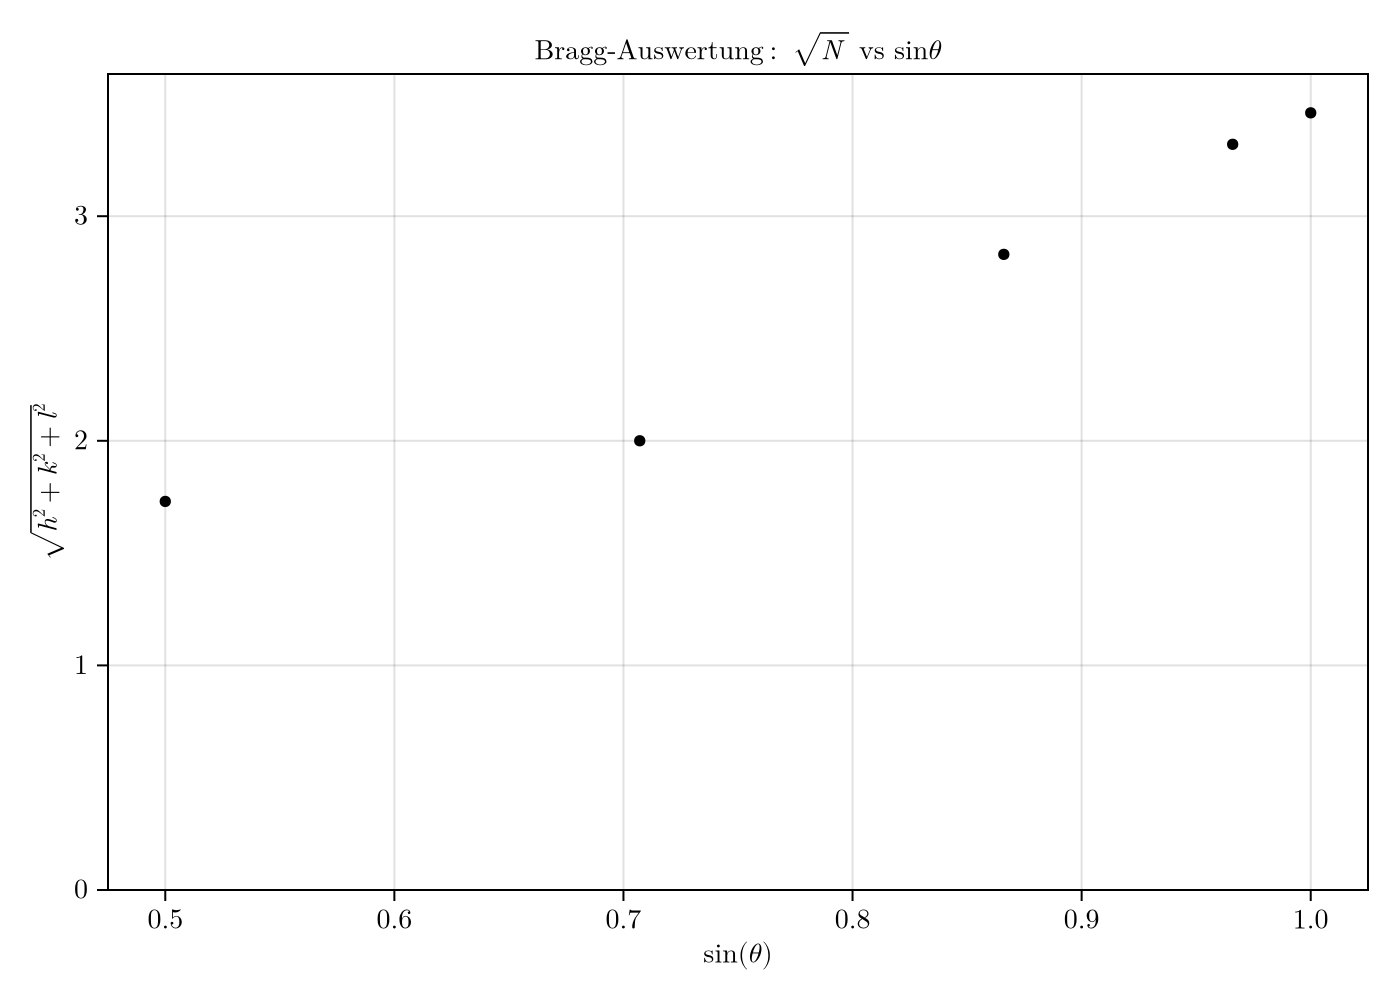

In [30]:
function nice_ticks_and_labels(x, n_labels=11, sigdigit=8)
    xmin, xmax = minimum(x), maximum(x)
    if xmin == xmax
        return [xmin], [string(xmin)]
    end
    order = Float64(floor(Int, log10(xmax - xmin + 1e-12)))
    n = Float64(floor(Int, xmax / 10^order)) + 1
    tick_max = n * 10^order
    ticks  = round.(collect(range(0.0, stop=tick_max, step=5*10^(order-2))); digits=sigdigit)
    labels = collect(range(0.0, stop=tick_max, length=n_labels))
    return ticks, labels
end

function alignedlabels(ticks, labels; atol=0.06)
    aligned = String[]
    for x in ticks
        match = findfirst(lbl -> isapprox(x, lbl; atol=atol, rtol=0), labels)
        if match === nothing
            push!(aligned, "")
        else
            push!(aligned, string(labels[match]))
        end
    end
    return aligned
end

# Sicherstellen, dass die benötigten Variablen definiert sind
t_data = @isdefined(t) ? t : table([30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360])
th_val = @isdefined(th) ? th : t_data.sin_theta
root_val = @isdefined(root) ? root : t_data.sqrtN_fcc
delth_val = @isdefined(delth) ? delth : 0.0

# Ersten Eintrag (N=0, hkl=(0,0,0)) weglassen und nur theta <= 90° betrachten
valid_indices = findall(idx -> t_data.theta[idx] <= 90.0 && t_data.sqrtN_fcc[idx] > 0.0, 1:length(t_data.theta))
x = th_val[valid_indices]       # sin(θ)
y = root_val[valid_indices]     # √(h²+k²+l²)
Δx = delth_val                  # Fehler auf sin(θ)

with_theme(theme_latexfonts()) do
    fig = Figure(size=(700, 500))
    ax  = Axis(fig[1,1],
        title  = L"Bragg-Auswertung: $\sqrt{N}$ vs $\sin\theta$",
        xlabel = L"$\sin(\theta)$",
        ylabel = L"$\sqrt{h^2+k^2+l^2}$")

    # Skalierung automatisch aus Datenpunkten
    xpad = 0.05 * (maximum(x) - minimum(x) + 1e-6)
    ypad = 0.1  * (maximum(y) - minimum(y) + 1e-6)
    xlims!(ax, minimum(x) - xpad, maximum(x) + xpad)
    ylims!(ax, 0.0, maximum(y) + ypad)

    # Fehlerbalken nur in x (Δx = delth)
    errorbars!(ax, x, y, fill(Δx, length(x)), color=:grey, whiskerwidth=5, direction=:x)

    # Datenpunkte
    scatter!(ax, x, y, markersize=8, color=:black)

    save("bragg_plot.png", fig, px_per_unit = 2)
    fig
end
